In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import zipfile
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset, random_split
from torchvision import datasets, transforms, models
import matplotlib.pyplot as plt
import numpy as np
import time
import copy
from tqdm import tqdm

# Set random seed for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Check device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [ ]:
# Create a directory for the dataset
os.makedirs('/content/catdog', exist_ok=True)

# Paths to your zip files in Drive (adjust if you placed them elsewhere)
train_zip = '/content/drive/MyDrive/kaggle_heart_disease/cat-dog-dataset/training_set.zip'
test_zip = '/content/drive/MyDrive/kaggle_heart_disease/cat-dog-dataset/test_set.zip'

# Unzip training set
with zipfile.ZipFile(train_zip, 'r') as zip_ref:
    zip_ref.extractall('/content/catdog/training')

# Unzip test set
with zipfile.ZipFile(test_zip, 'r') as zip_ref:
    zip_ref.extractall('/content/catdog/test')

print("Unzipped!")

Unzipped!


In [ ]:
# For pretrained models (ResNet, VGG) we need ImageNet normalization
pretrained_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# For the simple CNN we only resize and convert to tensor (no normalization)
simple_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

# Load datasets with different transforms

In [ ]:
data_dir = '/content/catdog/training'

# Create two dataset objects with the two transforms
full_dataset_pretrained = datasets.ImageFolder(root=data_dir, transform=pretrained_transform)
full_dataset_simple = datasets.ImageFolder(root=data_dir, transform=simple_transform)

# Total number of images
total_size = len(full_dataset_pretrained)
train_size = int(0.8 * total_size)
val_size = total_size - train_size

# Generate indices for train/val split (same for both datasets)
indices = list(range(total_size))
np.random.shuffle(indices)
train_indices = indices[:train_size]
val_indices = indices[train_size:]

# Create subsets using the same indices
train_dataset_pretrained = Subset(full_dataset_pretrained, train_indices)
val_dataset_pretrained = Subset(full_dataset_pretrained, val_indices)

train_dataset_simple = Subset(full_dataset_simple, train_indices)
val_dataset_simple = Subset(full_dataset_simple, val_indices)

# DataLoader parameters
batch_size = 32
num_workers = 2

# Dataloaders for pretrained models
dataloaders_pretrained = {
    'train': DataLoader(train_dataset_pretrained, batch_size=batch_size,
                        shuffle=True, num_workers=num_workers),
    'val': DataLoader(val_dataset_pretrained, batch_size=batch_size,
                      shuffle=False, num_workers=num_workers)
}

# Dataloaders for simple CNN
dataloaders_simple = {
    'train': DataLoader(train_dataset_simple, batch_size=batch_size,
                        shuffle=True, num_workers=num_workers),
    'val': DataLoader(val_dataset_simple, batch_size=batch_size,
                      shuffle=False, num_workers=num_workers)
}

# Dataset sizes for each split
dataset_sizes_pretrained = {
    'train': len(train_dataset_pretrained),
    'val': len(val_dataset_pretrained)
}
dataset_sizes_simple = {
    'train': len(train_dataset_simple),
    'val': len(val_dataset_simple)
}

print(f"Training samples: {train_size}, Validation samples: {val_size}")

Training samples: 6404, Validation samples: 1601


# Simple CNN

In [ ]:
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=2):
        super(SimpleCNN, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 28 * 28, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

# Pretrained ResNet18

In [ ]:
def get_resnet18(num_classes=2):
    model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
    # Freeze all layers
    for param in model.parameters():
        param.requires_grad = False
    # Replace classifier
    num_ftrs = model.fc.in_features
    model.fc = nn.Linear(num_ftrs, num_classes)
    return model

# Pretrained VGG16

In [ ]:
def get_vgg16(num_classes=2):
    model = models.vgg16_bn(weights=models.VGG16_BN_Weights.IMAGENET1K_V1)
    # Freeze all layers
    for param in model.parameters():
        param.requires_grad = False
    # Replace classifier
    num_ftrs = model.classifier[6].in_features
    model.classifier[6] = nn.Linear(num_ftrs, num_classes)
    return model

# Training function with tqdm progress bars


In [ ]:
def train_model(model, criterion, optimizer, scheduler, num_epochs, dataloaders, dataset_sizes):
    since = time.time()
    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0

    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

    for epoch in range(num_epochs):
        print(f'\nEpoch {epoch+1}/{num_epochs}')
        print('-' * 60)

        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()
                data_loader = tqdm(dataloaders[phase], desc='Training', leave=False)
            else:
                model.eval()
                data_loader = tqdm(dataloaders[phase], desc='Validation', leave=False)

            running_loss = 0.0
            running_corrects = 0

            for inputs, labels in data_loader:
                inputs = inputs.to(device)
                labels = labels.to(device)

                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)

                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                # Statistics
                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

                # Update progress bar
                data_loader.set_postfix({
                    'loss': f'{loss.item():.4f}',
                    'acc': f'{torch.sum(preds == labels.data).item()/inputs.size(0):.4f}'
                })

            if phase == 'train' and scheduler:
                scheduler.step()

            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_acc = running_corrects.double() / dataset_sizes[phase]

            history[f'{phase}_loss'].append(epoch_loss)
            history[f'{phase}_acc'].append(epoch_acc.item())

            print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

            if phase == 'val' and epoch_acc > best_acc:
                best_acc = epoch_acc
                best_model_wts = copy.deepcopy(model.state_dict())

    time_elapsed = time.time() - since
    print(f'\nTraining complete in {time_elapsed//60:.0f}m {time_elapsed%60:.0f}s')
    print(f'Best val Acc: {best_acc:.4f}')

    model.load_state_dict(best_model_wts)
    return model, history

# Train Each Model

In [ ]:
models_to_train = {
    'SimpleCNN': (SimpleCNN(num_classes=2), dataloaders_simple, dataset_sizes_simple),
    'ResNet18 (pretrained)': (get_resnet18(), dataloaders_pretrained, dataset_sizes_pretrained),
    'VGG16 (pretrained)': (get_vgg16(), dataloaders_pretrained, dataset_sizes_pretrained)
}

results = {}

for name, (model, dataloaders, dataset_sizes) in models_to_train.items():
    print(f"\n========== Training {name} ==========")
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    # Only train parameters that require gradients (the new head for pretrained models)
    optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=0.001)
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=7, gamma=0.1)

    trained_model, history = train_model(
        model, criterion, optimizer, scheduler,
        num_epochs=10,
        dataloaders=dataloaders,
        dataset_sizes=dataset_sizes
    )
    results[name] = history


========== Training SimpleCNN ==========

Epoch 1/10
------------------------------------------------------------


train Loss: 0.0035 Acc: 0.9952


val Loss: 0.0000 Acc: 1.0000

Epoch 2/10
------------------------------------------------------------


train Loss: 0.0000 Acc: 1.0000


val Loss: 0.0000 Acc: 1.0000

Epoch 3/10
------------------------------------------------------------


...

val Loss: 0.0000 Acc: 1.0000

Epoch 9/10
------------------------------------------------------------


train Loss: 0.0000 Acc: 1.0000


val Loss: 0.0000 Acc: 1.0000

Epoch 10/10
------------------------------------------------------------


train Loss: 0.0000 Acc: 1.0000


val Loss: 0.0000 Acc: 1.0000

Training complete in 8m 29s
Best val Acc: 1.0000


In [ ]:
print(f"Total images: {total_size}")
print(f"Training images: {train_size}")
print(f"Validation images: {val_size}")

Total images: 8005
Training images: 6404
Validation images: 1601


In [ ]:
# After creating subsets, get the underlying file paths
train_paths = [full_dataset_pretrained.samples[i][0] for i in train_indices]
val_paths = [full_dataset_pretrained.samples[i][0] for i in val_indices]
print("Train paths sample:", train_paths[:5])
print("Val paths sample:", val_paths[:5])
print("Overlap:", set(train_paths) & set(val_paths))  # should be empty

Train paths sample: ['/content/catdog/training/training_set/dogs/dog.625.jpg', '/content/catdog/training/training_set/dogs/dog.3063.jpg', '/content/catdog/training/training_set/dogs/dog.3742.jpg', '/content/catdog/training/training_set/cats/cat.2896.jpg', '/content/catdog/training/training_set/dogs/dog.2417.jpg']
Val paths sample: ['/content/catdog/training/training_set/dogs/dog.3601.jpg', '/content/catdog/training/training_set/dogs/dog.740.jpg', '/content/catdog/training/training_set/dogs/dog.1899.jpg', '/content/catdog/training/training_set/dogs/dog.2666.jpg', '/content/catdog/training/training_set/cats/cat.215.jpg']
Overlap: set()


# Comparison and Visualization

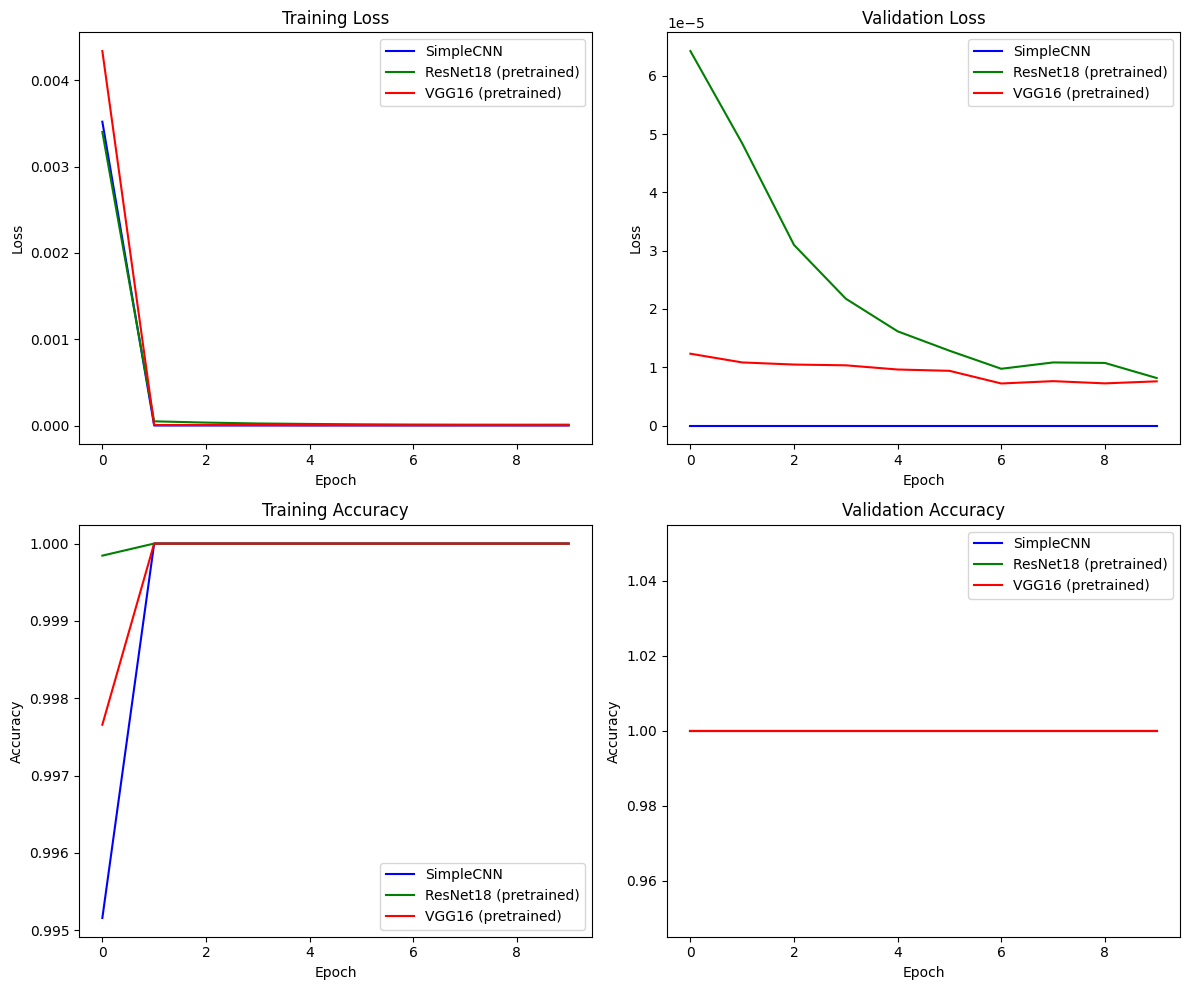

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

colors = {'SimpleCNN': 'blue', 'ResNet18 (pretrained)': 'green', 'VGG16 (pretrained)': 'red'}

# Plot training loss
for name, hist in results.items():
    axes[0].plot(hist['train_loss'], label=name, color=colors[name])
axes[0].set_title('Training Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

# Plot validation loss
for name, hist in results.items():
    axes[1].plot(hist['val_loss'], label=name, color=colors[name])
axes[1].set_title('Validation Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

# Plot training accuracy
for name, hist in results.items():
    axes[2].plot(hist['train_acc'], label=name, color=colors[name])
axes[2].set_title('Training Accuracy')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('Accuracy')
axes[2].legend()

# Plot validation accuracy
for name, hist in results.items():
    axes[3].plot(hist['val_acc'], label=name, color=colors[name])
axes[3].set_title('Validation Accuracy')
axes[3].set_xlabel('Epoch')
axes[3].set_ylabel('Accuracy')
axes[3].legend()

plt.tight_layout()
plt.show()

# Print final validation accuracy


In [ ]:
print("\nFinal Validation Accuracy after 10 epochs:")
for name, hist in results.items():
    final_acc = hist['val_acc'][-1]
    print(f"{name}: {final_acc:.4f}")


Final Validation Accuracy after 10 epochs:
SimpleCNN: 1.0000
ResNet18 (pretrained): 1.0000
VGG16 (pretrained): 1.0000
